# 1. Generate Training Data
### 1.1 Diffraction
The angular spectrum diffraction formula is used: $A=F^{-1}[F(P)\cdot H]$, where $H$ is the transfer function.

$$
\begin{aligned}
H=e^{jkz\sqrt{1-\lambda^2(f_x^2-f_y^2)}}
\end{aligned}
$$

Diffraction pattern: $A$, corresponding to the **input** of the UNet.

Phase: $P$, corresponding to the **output** of the UNet.

### <span style="color:green;">【import】</span>

In [60]:

globals().clear()

import os
import random
import math
import csv
import re

import cv2
import numpy as np
import scipy.io as scio
import scipy.io as sio
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error as compare_mse

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.fft import fft2, ifft2, fftshift, ifftshift

from tqdm import tqdm
from optparse import OptionParser


os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### <span style="color:green;">【angular spectrum propagation】</span>

In [61]:

' Forward diffraction propagation in pytorch (cuda)'

def propagation(P,  prop_dis=20, norm=False, dim = 256, pad=None):
    A = np.ones((dim, dim))
    A = torch.from_numpy(A).to(device).unsqueeze(0).unsqueeze(0)

    if pad:
        p2d = (int(dim/4), int(dim/4), int(dim/4), int(dim/4))  # pad last dim and 2nd to last
        A = F.pad(A, p2d, "replicate") # pad A
        P = F.pad(P, p2d, "replicate") # pad P

    U_O = A * torch.exp(1j * P)  # complex-valued amplitudes on object plane
    lamb = 632.8e-6  # wavelength
    pixel_size = 8e-3  # pixel size
    pixel_num = dim  # pixel number
    if pad:
        pixel_num = dim + int(dim / 2)
    len = pixel_num * pixel_size  # field of view length
    k = 2 * math.pi / lamb  # wave number

    # frequency domain sampling
    f = 1 / len
    f = f * np.linspace(-pixel_num / 2, pixel_num / 2 - 1, pixel_num)
    [Fx, Fy] = np.meshgrid(f, f)

    # propagation function
    H = torch.exp(1j * k * prop_dis * torch.sqrt(torch.tensor(1 - lamb * lamb * (Fx * Fx + Fy * Fy)))).to(device)

    # propagation from Object plane to Imaging plane
    UO_FFT = ifftshift(fft2(fftshift(U_O)))
    UI = ifftshift(ifft2(fftshift(UO_FFT * H)))

    # get hologram on the Imaging plane
    H = torch.abs(UI) * torch.abs(UI)

    # take the middle area, if padding is used
    if pad:
        H = H[:, :, int(dim/4):(dim+int(dim/4)), int(dim/4):(dim+int(dim/4))]

    # normalize the hologram to [0,1]
    if norm:
        H_max = H.max(3)[0].max(2)[0].unsqueeze(2).unsqueeze(3).repeat(1, 1, dim, dim)
        H_min = H.min(3)[0].min(2)[0].unsqueeze(2).unsqueeze(3).repeat(1, 1, dim, dim)
        H = torch.div((H - H_min), (H_max - H_min))

    return H


### <span style="color:green;">【Diffraction Propagation Demonstration】</span>

Select an image for demonstration.  **Amplitude (input)** represents the image-plane diffraction pattern,  while **Phase (out)** denotes the object-plane phase.

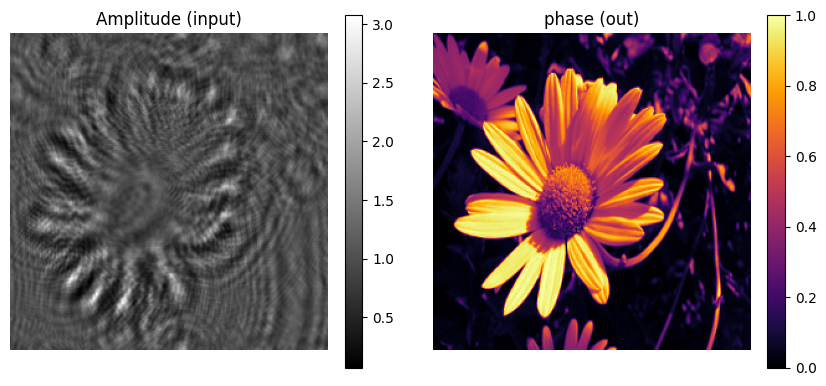

In [62]:
dir_images="./img_set/"  #图片文件夹路径
image_list = sorted(os.listdir(dir_images))
dim=256 #图片大小
img = cv2.imread(os.path.join(dir_images, image_list[3]), cv2.IMREAD_GRAYSCALE)  # read image in grayscale mode
P1 = cv2.resize(img, (dim, dim)) #重塑图片大小
P1 = (P1 - np.min(P1)) / (np.max(P1) - np.min(P1))
rand = random.uniform(1,1)
P1 = P1 * rand
P1 = torch.from_numpy(P1).to(device).unsqueeze(0).unsqueeze(0)  #在前面增加两个维度
A1 = propagation(P1, prop_dis=20, norm=False, dim=256, pad=False)# 衍射传播计算
A1 = A1[0, 0, :, :].cpu().numpy()  # 去掉前两个维度
P1 = P1[0, 0, :, :].cpu().numpy()

plt.figure(figsize=(10, 6))
plt.subplot(121)
plt.imshow(A1, cmap="gray")
plt.title('Amplitude (input)')
plt.colorbar(fraction=0.05, pad=0.05)
plt.axis('off')
plt.subplot(122)
plt.imshow(P1, cmap="inferno")
plt.title('phase (out)')
plt.colorbar(fraction=0.05, pad=0.05)
plt.axis('off')
plt.show()

### 1.2 Generate Dataset

Call the `propagation` function to sequentially perform diffraction calculations on images from the "img_set" image folder, generating multiple pairs of input (A) and output (P) data.

### <span style="color:green;">【Partition the dataset into training set and test set】</span>

In [63]:
image_list = sorted(os.listdir(dir_images))
#image_list = os.listdir(dir_images)  # paths of row images
dir_train_in='./data/train_in/'
dir_train_gt='./data/train_gt/'
dir_test_in='./data/test_in/'
dir_test_gt='./data/test_gt/'
# Creat folders for data
os.makedirs(dir_train_in, exist_ok=True)
os.makedirs(dir_train_gt, exist_ok=True)
os.makedirs(dir_test_in, exist_ok=True)
os.makedirs(dir_test_gt, exist_ok=True)

    # generate paired datasets (holograms-phases)
for ii, img_name in enumerate(image_list, 1):
        img_path = dir_images + img_name  # path of a row image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # read image in grayscale mode
        P = cv2.resize(img, (dim, dim))  # get Phase

        # Set Phase to range of [0, h], where h is distributed in [p_min, p_max]
        P = (P - np.min(P)) / (np.max(P) - np.min(P))
        rand = random.uniform(1, 1)
        P = P * rand

        P = torch.from_numpy(P).to(device).unsqueeze(0).unsqueeze(0)  # phase to torch (cuda)
        H = propagation(P, prop_dis=20, norm=False, dim=256, pad=False)  # Get holograms for phase samples
        H = H[0, 0, :, :].cpu().numpy()  # holograms to numpy
        P = P[0, 0, :, :].cpu().numpy()  # phases to numpy

        # save holograms and phases
        if ii <= int(0.96*(len(image_list))):
            scio.savemat(dir_train_in + '%06d.mat' % (ii), {'input': H})
            scio.savemat(dir_train_gt + '%06d.mat' % (ii), {'gt': P})
        else:
            scio.savemat(dir_test_in + '%06d.mat' % (ii), {'input': H})
            scio.savemat(dir_test_gt + '%06d.mat' % (ii), {'gt': P})
        print("Generating dataset, %.2f %%" % (100*ii/len(image_list)))

Generating dataset, 1.00 %
Generating dataset, 2.00 %
Generating dataset, 3.00 %
Generating dataset, 4.00 %
Generating dataset, 5.00 %
Generating dataset, 6.00 %
Generating dataset, 7.00 %
Generating dataset, 8.00 %
Generating dataset, 9.00 %
Generating dataset, 10.00 %
Generating dataset, 11.00 %
Generating dataset, 12.00 %
Generating dataset, 13.00 %
Generating dataset, 14.00 %
Generating dataset, 15.00 %
Generating dataset, 16.00 %
Generating dataset, 17.00 %
Generating dataset, 18.00 %
Generating dataset, 19.00 %
Generating dataset, 20.00 %
Generating dataset, 21.00 %
Generating dataset, 22.00 %
Generating dataset, 23.00 %
Generating dataset, 24.00 %
Generating dataset, 25.00 %
Generating dataset, 26.00 %
Generating dataset, 27.00 %
Generating dataset, 28.00 %
Generating dataset, 29.00 %
Generating dataset, 30.00 %
Generating dataset, 31.00 %
Generating dataset, 32.00 %
Generating dataset, 33.00 %
Generating dataset, 34.00 %
Generating dataset, 35.00 %
Generating dataset, 36.00 %
G

## 2. Define the UNet Network

In [64]:
import torch.nn as nn
from torch import cat as cat

' Branch0 block '
class Branch0(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Branch0, self).__init__()
        self.conv0 = nn.Conv2d(in_ch, out_ch, kernel_size=1, padding=0)
        self.bt0 = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        x0 = self.conv0(x)
        x0 = self.bt0(x0)
        return x0

' Branch1 block '
class Branch1(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Branch1, self).__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bt1 = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        x1 = self.conv1(x)
        x1 = self.bt1(x1)
        return x1

' Branch2 block '
class Branch2(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Branch2, self).__init__()
        self.conv2_1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bt2_1 = nn.BatchNorm2d(out_ch)
        self.rl2_1 = nn.LeakyReLU(inplace=True)
        self.conv2_2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bt2_2 = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        x2 = self.conv2_1(x)
        x2 = self.bt2_1(x2)
        x2 = self.rl2_1(x2)
        x2 = self.conv2_2(x2)
        x2 = self.bt2_2(x2)
        return x2

' Branch3 block '
class Branch3(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Branch3, self).__init__()
        self.conv3_1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bt3_1 = nn.BatchNorm2d(out_ch)
        self.rl3_1 = nn.LeakyReLU(inplace=True)
        self.conv3_2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bt3_2 = nn.BatchNorm2d(out_ch)
        self.rl3_2 = nn.LeakyReLU(inplace=True)
        self.conv3_3 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bt3_3 = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        x3 = self.conv3_1(x)
        x3 = self.bt3_1(x3)
        x3 = self.rl3_1(x3)
        x3 = self.conv3_2(x3)
        x3 = self.bt3_2(x3)
        x3 = self.rl3_2(x3)
        x3 = self.conv3_3(x3)
        x3 = self.bt3_3(x3)
        return x3

' Branch4 block '
class Branch4(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Branch4, self).__init__()
        self.conv4_1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bt4_1 = nn.BatchNorm2d(out_ch)
        self.rl4_1 = nn.LeakyReLU(inplace=True)
        self.conv4_2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bt4_2 = nn.BatchNorm2d(out_ch)
        self.rl4_2 = nn.LeakyReLU(inplace=True)
        self.conv4_3 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bt4_3 = nn.BatchNorm2d(out_ch)
        self.rl4_3 = nn.LeakyReLU(inplace=True)
        self.conv4_4 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bt4_4 = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        x4 = self.conv4_1(x)
        x4 = self.bt4_1(x4)
        x4 = self.rl4_1(x4)
        x4 = self.conv4_2(x4)
        x4 = self.bt4_2(x4)
        x4 = self.rl4_2(x4)
        x4 = self.conv4_3(x4)
        x4 = self.bt4_3(x4)
        x4 = self.rl4_3(x4)
        x4 = self.conv4_4(x4)
        x4 = self.bt4_4(x4)
        return x4

' Residual block with Inception module '
class ResB(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(ResB, self).__init__()
        self.branch0 = Branch0(in_ch, out_ch)
        self.branch1 = Branch1(in_ch, out_ch // 4)
        self.branch2 = Branch2(in_ch, out_ch // 4)
        self.branch3 = Branch3(in_ch, out_ch // 4)
        self.branch4 = Branch4(in_ch, out_ch // 4)
        self.rl = nn.LeakyReLU(inplace=True)
    def forward(self, x):
        x0 = self.branch0(x)
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        x4 = self.branch4(x)
        x5 = cat((x1, x2, x3, x4), dim=1)
        x6 = x0 + x5
        x7 = self.rl(x6)
        return x7

' Downsampling block '
class DownB(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DownB, self).__init__()
        self.res = ResB(in_ch, out_ch) # ResB_simple or ResB
        self.pool = nn.MaxPool2d(kernel_size=2)
    def forward(self, x):
        x1 = self.res(x)
        x2 = self.pool(x1)
        return x2, x1

' Upsampling block '
class UpB(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(UpB, self).__init__()
        self.up = nn.ConvTranspose2d(
                in_ch, out_ch, kernel_size=3, stride=2, padding = 1, output_padding = 1 )
        self.res = ResB(out_ch*2, out_ch) # ResB_simple or ResB
    def forward(self, x, x_):
        x1 = self.up(x)
        x2 = cat((x1 , x_), dim=1)
        x3 = self.res(x2)
        return x3

' Output layer '
class Outconv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Outconv, self).__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1, padding=0)
    def forward(self, x):
        x1 = self.conv(x)
        return x1

' Architecture of Res-UNet '
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.down1 = DownB(1, 64)
        self.down2 = DownB(64, 128)
        self.down3 = DownB(128, 256)
        self.down4 = DownB(256, 512)
        self.res = ResB(512, 1024)
        self.up1 = UpB(1024, 512)
        self.up2 = UpB(512, 256)
        self.up3 = UpB(256, 128)
        self.up4 = UpB(128, 64)
        self.outc = Outconv(64, 1)

    def forward(self, x):
        x1, x1_ = self.down1(x)
        x2, x2_ = self.down2(x1)
        x3, x3_ = self.down3(x2)
        x4, x4_ = self.down4(x3)
        x5  = self.res(x4)
        x6  = self.up1(x5, x4_)
        x7  = self.up2(x6, x3_)
        x8  = self.up3(x7, x2_)
        x9  = self.up4(x8, x1_)
        x10 = self.outc(x9)
        return x10

## 3. Define the Train-function

### <span style="color:green;">Cumulative Average Loss Calculation</span>

Where $n$ is the size of a batch ($batchsize$). For example, if there are 50 images in total and the batch size is set to $batchsize=10$, the dataset can be divided into 5 batches. The neural network is trained with $epochs=100$ iterations, and each iteration requires running all 5 batches completely.

The function returns the average loss $avg$ of these images processed in one batch during a single iteration.

In [65]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

### <span style="color:green;">Data-Driven Model</span>

Data-driven means that the loss function is calculated using only the **MSE loss** between the network output and the target.

In [66]:
' network training function for DD'
def train_net_DD(net, device, loader, optimizer, loss_f):
    net.train()
    train_loss = AverageMeter()
    for batch_idx, (input, gt) in enumerate(loader):
        input, gt = input.to(device), gt.to(device)  # Send data to GPU
        output = net(input)  # Network forward
        loss = loss_f(output, gt)  # Loss calculation
        train_loss.update(loss.item(), output.size(0))  # Update the record

        # Back propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return train_loss.avg, input, output, gt

### <span style="color:green;">Physics-Constrained Model</span>

Physics constraint means that the network output $P_{new}$ is mapped to $A_{new}$ using the physical propagation function $P(\cdot)$ again, and then the MSE loss is calculated between $A_{new}$ and the original target $A$.

In [72]:
' network training function for PD'
def train_net_PD(net, device, loader, optimizer, loss_f, prop_dis=20, norm=False, rand_to_holo=False, dim=256, pad=False):
    net.train()
    train_loss = AverageMeter()
    for batch_idx, (input, gt) in enumerate(loader):
        input, gt = input.to(device), gt.to(device) # Send data to GPU

        # Add rand to hologram
        if rand_to_holo:
            rand = torch.rand((1, 1, dim, dim)) * (1.0/30)
            input = input + rand.to(device)

        output = net(input)  # network forward
        H = propagation(output, prop_dis=prop_dis, norm=norm, dim=dim, pad=pad)
        loss = loss_f(input, H)  # Loss calculation
        train_loss.update(loss.item(), output.size(0))  # Update the record

        # Back propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss.avg, input,  output, gt

### <span style="color:green;">Hybrid-Driven Model</span>

The final loss function is obtained by performing normalized weighted summation on the data-driven loss loss0 and the physics-driven loss loss1.

In [73]:
' network training function for CD'
def train_net_CD(net, device, loader, optimizer, loss_f, prop_dis=20, norm=False, rand_to_holo=False, dim=256, alpha=0.3, pad=False):
    net.train()
    train_loss = AverageMeter()
    for batch_idx, (input, gt) in enumerate(loader):
        input, gt = input.to(device), gt.to(device) # Send data to GPU

        # Add rand to hologram
        if rand_to_holo:
            rand = torch.rand((1, 1, dim, dim)) * (1.0/30)
            input = input + rand.to(device)

        output = net(input)  # network forward
        H = propagation(output, prop_dis=prop_dis, norm=norm, dim=dim, pad=pad)
        loss0 = loss_f(output, gt)  # Loss calculation of DD
        loss1 = loss_f(input, H)  # Loss calculation of PD
        # loss = alpha*loss0 + loss1
        loss = alpha*loss0 + (1-alpha)*loss1

        train_loss.update(loss.item(), output.size(0))  # Update the record

        # Back propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss.avg, input,  output, gt

## 4. Main Training Procedure

### <span style="color:green;">Define Data Loading Function</span>

In [67]:

' Define the reading of the dataset '
class PUDataset(Dataset):
    def __init__(self, ids, dir_input, dir_gt, extension='.mat'):
        self.dir_input = dir_input
        self.dir_gt = dir_gt
        self.extension = extension
        self.ids = ids  # Dataset IDS
        self.data_len = len(self.ids)  # Calculate len of data

    ' Ask for input and ground truth'
    def __getitem__(self, index):
        # Get an ID of the input and ground truth
        id_input = self.dir_input + self.ids[index] + self.extension
        id_gt = self.dir_gt + self.ids[index] + self.extension
        # Open them
        input = sio.loadmat(id_input)
        gt = sio.loadmat(id_gt)
        input = input['input']
        gt = gt['gt']
        input = torch.from_numpy(input).float().unsqueeze(0)
        gt = torch.from_numpy(gt).float().unsqueeze(0)
        return (input, gt)

    ' Length of the dataset '
    def __len__(self):
        return self.data_len

' Return the training dataset separated in batches '
def get_dataloaders(dir_input, dir_gt, batch_size=10):
    ids = [f[:-4] for f in os.listdir(dir_input)]  # Read the names of the images
    dset = PUDataset(ids, dir_input, dir_gt)  # Get the dataset
    dataloaders = DataLoader(dset, batch_size=batch_size, shuffle=True, drop_last=False)  # Create the dataloaders
    return dataloaders

def get_dataloader_for_test(dir_img, dir_gt):
    ids = [f[:-4] for f in sorted(os.listdir(dir_img))]  # Read the names of the datas
    dset = PUDataset(ids, dir_img, dir_gt)  # Get the dataset
    dataloader = DataLoader(dset, batch_size=len(ids))  # Create the dataloader
    return dataloader

### <span style="color:green;">【Training Procedure】</span>

In [ ]:

' Run of the training '
dir_input='./data/train_in/'
dir_gt='./data/train_gt/'
dir_model='./models_and_results/model_weights/'
batch_size=20
strategy = "CD"
epochs=500
lr=0.001
rth=False
alpha=0.3
pad=False


# Create the model
net = UNet().to(device)
net.train()
net = torch.nn.DataParallel(net, device_ids=list(range(torch.cuda.device_count()))).to(device)

# dataset loader
train_loader = get_dataloaders(dir_input, dir_gt, batch_size)

# Definition of the optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=0.00)

# Definition of the loss function
loss_f = torch.nn.L1Loss()

# Set the header for csv
header = ['epoch', 'learning rate', 'train loss']

# set the best loss for model weights saving
best_loss = 1000000

train_loss_history = []
epoch_list = []

# Generate a folder for network training data
if not os.path.exists(dir_model):
    os.makedirs(dir_model)

# Ready to use the tqdm
for epoch in range(epochs):
   

   if lr > 0.00001:
       if epoch % 10 == 0:
           lr = lr * 0.95
   

    # network training with DD, tPD, or CD
   if strategy == "DD":
        train_loss, input, output, gt = train_net_DD(net, device, train_loader, optimizer, loss_f)
   elif strategy == "PD":
        train_loss, input, output, gt = train_net_PD(net, device, train_loader, optimizer, loss_f, prop_dis=20,norm=False, rand_to_holo=rth, dim=dim, pad=pad)
   elif strategy == "CD":
        train_loss, input, output, gt = train_net_CD(net, device, train_loader, optimizer, loss_f, prop_dis=20,norm=False, rand_to_holo=rth, dim=dim, alpha=alpha, pad=pad)
   else:
    raise Exception("invalid training strategy")

   #print('\nLearning rate=', round(lr, 6))
   #print('Training loss=', round(train_loss, 6))
   print(f'\rEpoch [{epoch+1}/{epochs}] [00:08<03:25, 2.14s/it] | LR: {lr:.6f} | Loss: {train_loss:.6f}        ', end='', flush=True)

   # see results in training
   if (epoch == 0 or (epoch+1) % 50 == 0):
       plt.figure(figsize=(10, 6))
       plt.subplot(131)
       plt.imshow(input[0, 0, :, :].cpu().numpy(), cmap='gray')
       plt.title('input (hologram)')
       plt.colorbar(fraction=0.05, pad=0.05)
       plt.axis('off')
       plt.subplot(132)
       output_np = output[0, 0, :, :].detach().cpu().numpy()
       output_np = output_np - np.min(output_np)
       plt.imshow(output_np, cmap="inferno")
       plt.title('output (phase)')
       plt.colorbar(fraction=0.05, pad=0.05)
       plt.axis('off')
       plt.subplot(133)
       plt.imshow(gt[0, 0, :, :].detach().cpu().numpy(), cmap="inferno")
       plt.title('gt (phase)')
       plt.colorbar(fraction=0.05, pad=0.05)
       plt.axis('off')

       filename_plt = dir_model + strategy + '_' + (str(epoch + 1).zfill(6)) + '_in_out_gt.png'
       plt.savefig(filename_plt)
       #plt.show()
       plt.close()

   epoch_list.append(epoch+1)
   train_loss_history.append(train_loss)

   values = [epoch+1, lr, train_loss]
   path_csv = dir_model + strategy + "_loss_and_others" + ".csv"
   if os.path.isfile(path_csv) == False:
       file = open(path_csv, 'w', newline='')
       writer = csv.writer(file)
       writer.writerow(header)
       writer.writerow(values)
   else:
       file = open(path_csv, 'a', newline='')
       writer = csv.writer(file)
       writer.writerow(values)
   file.close()

   if train_loss < best_loss:
    best_loss = train_loss
    torch.save({
                'epoch': epoch + 1,
                'state_dict': net.state_dict(),
                'loss': train_loss,
                'optimizer': optimizer.state_dict(),
                }, dir_model + strategy + "_weights" + ".pth")

    # Save model



Epoch [500/500] [00:08<03:25, 2.14s/it] | LR: 0.000077 | Loss: 0.036800        

### <span style="color:green;">【loss curve】</span>

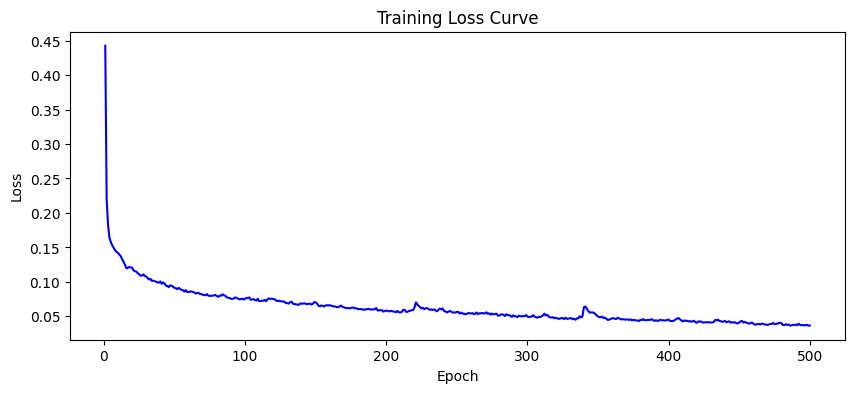

In [86]:
plt.figure(figsize=(10, 4))
plt.plot(epoch_list, train_loss_history, color="blue", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

filename_plt = './' + strategy + '_loss.png'
plt.savefig(filename_plt)
plt.show()

### <span style="color:green;">【Test Set Evaluation】</span>

[1, 0.059283187562367015]
[2, 0.012845466923490421]
[3, 0.02572899818730619]
[4, 0.029523306062480204]


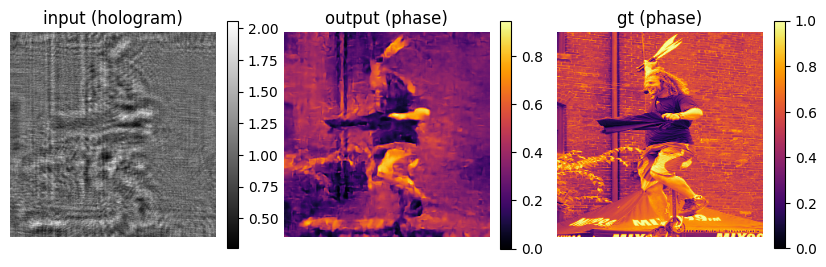

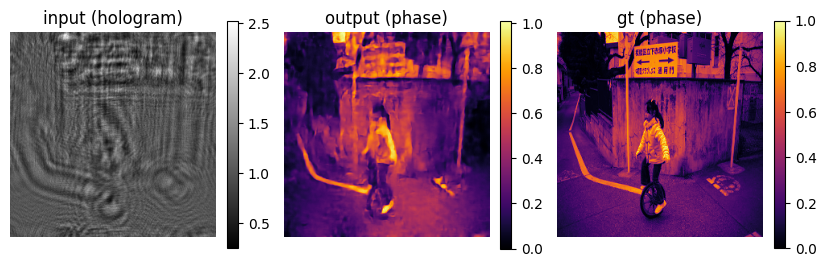

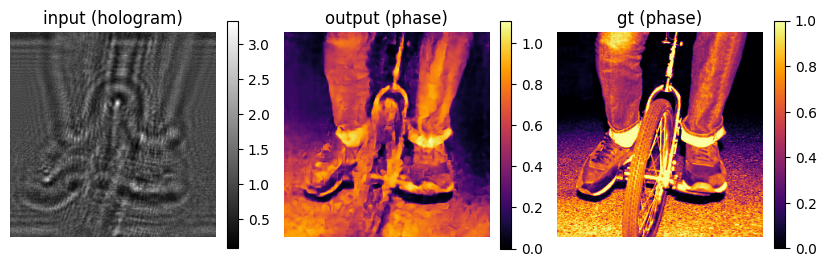

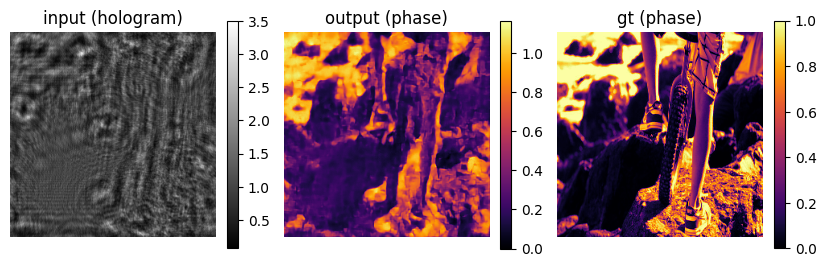

In [81]:
load_weights = './models_and_results/model_weights/'
dir_input = './data/test_in/'
dir_gt = './data/test_gt/'
resultdir = './models_and_results/results_DD_tPD_CD/'
strategy = "CD"
# Generate a folder for model weights and network results
if not os.path.exists(resultdir):
    os.makedirs(resultdir)

# Create the model
net = UNet().to(device)
net.eval()
net = torch.nn.DataParallel(net, device_ids=list(range(torch.cuda.device_count()))).to(device)

# Load old weights
if strategy == 'DD':
    checkpoint = torch.load(load_weights + "DD_weights.pth", map_location='cpu')
elif strategy == 'PD':
    checkpoint = torch.load(load_weights + "PD_weights.pth", map_location='cpu')
elif strategy == 'CD':
    checkpoint = torch.load(load_weights + "CD_weights.pth", map_location='cpu')
else:
    raise Exception("invalid inference strategy")
net.load_state_dict(checkpoint['state_dict'])
net.eval()

# Load the dataset
loader = get_dataloader_for_test(dir_input, dir_gt)

# Set the header for csv
header = ['No.', 'mse']


with torch.no_grad():
    for (input, gt) in loader:
        input, gt = input.to(device), gt.to(device)
        for th in range(0, len(input)):
            output = net(torch.unsqueeze(input[th], 0))

            input_numpy = input[th].squeeze(0).cpu().numpy()
            output_numpy = output.squeeze(0).squeeze(0).cpu().numpy()
            output_numpy = output_numpy - np.min(output_numpy)
            gt_numpy = gt[th].squeeze(0).cpu().numpy()

            mse = compare_mse(output_numpy, gt_numpy)


            # Set the values for csv
            values = [th + 1, mse]
            print(values)
            # Save MSE to a csv

            path_csv = resultdir + strategy + "_MSE" + ".csv"
            if os.path.isfile(path_csv) == False:
                file = open(path_csv, 'w', newline='')
                writer = csv.writer(file)
                writer.writerow(header)
                writer.writerow(values)
            else:
                file = open(path_csv, 'a', newline='')
                writer = csv.writer(file)
                writer.writerow(values)
            file.close()

            # see results in cycle inference
            plt.figure(figsize=(10, 6))
            plt.subplot(131)
            plt.imshow(input_numpy, cmap='gray')
            plt.title('input (hologram)')
            plt.colorbar(fraction=0.05, pad=0.05)
            plt.axis('off')
            plt.subplot(132)
            plt.imshow(output_numpy, cmap="inferno")
            plt.title('output (phase)')
            plt.colorbar(fraction=0.05, pad=0.05)
            plt.axis('off')
            plt.subplot(133)
            plt.imshow(gt_numpy, cmap="inferno")
            plt.title('gt (phase)')
            plt.colorbar(fraction=0.05, pad=0.05)
            plt.axis('off')
            filename_plt = resultdir + strategy + '_sample' + (str(th + 1).zfill(6)) + '_results.png'
            plt.savefig(filename_plt)
            # plt.show()

            filename = resultdir + strategy + '_sample' + (str(th + 1).zfill(6)) + '_results.mat'
            sio.savemat(filename, {'input': input_numpy, 'output': output_numpy, 'gt': gt_numpy})


### <span style="color:green;">Generalization Test</span>

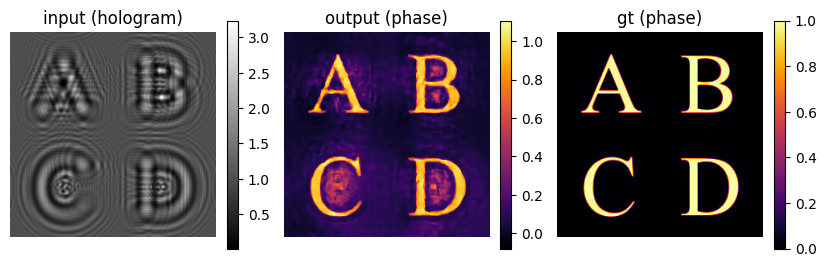

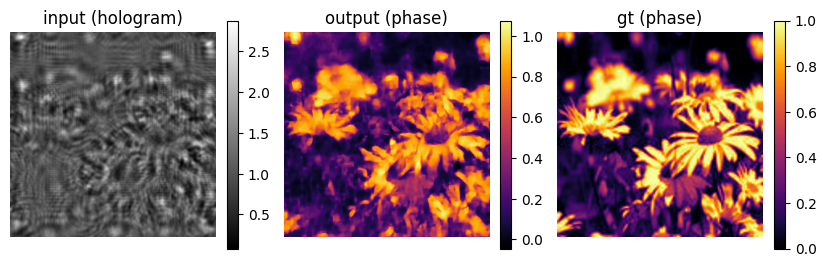

In [82]:
ge_list = sorted(os.listdir('./Generalization/'))
dim=256
strategy = 'CD'
load_weights = './models_and_results/model_weights/'
# Create the model
net = UNet().to(device)
net.eval()
net = torch.nn.DataParallel(net, device_ids=list(range(torch.cuda.device_count()))).to(device)

# Load old weights
if strategy == 'DD':
    checkpoint = torch.load(load_weights + "DD_weights.pth", map_location='cpu')
elif strategy == 'PD':
    checkpoint = torch.load(load_weights + "PD_weights.pth", map_location='cpu')
elif strategy == 'CD':
    checkpoint = torch.load(load_weights + "CD_weights.pth", map_location='cpu')
else:
    raise Exception("invalid inference strategy")
net.load_state_dict(checkpoint['state_dict'])
net.eval()

with torch.no_grad():
        for th, img_name in enumerate(ge_list, 1):
                ge_path = './Generalization/'+img_name
                img = cv2.imread(ge_path, cv2.IMREAD_GRAYSCALE)
                P = cv2.resize(img, (dim, dim))  # get Phase
                P = (P - np.min(P)) / (np.max(P) - np.min(P))
                rand = random.uniform(1, 1)
                P = P * rand
                P = torch.from_numpy(P).float().to(device).unsqueeze(0).unsqueeze(0)
                H = propagation(P, prop_dis=20, norm=False, dim=256, pad=False)

                P_out = net(H.float())
                P_out = P_out[0, 0, :, :].cpu().numpy()  # holograms to numpy
                P_gt = P[0, 0, :, :].cpu().numpy()  # phases to numpy
                H_in = H[0, 0, :, :].cpu().numpy()

                plt.figure(figsize=(10, 6))
                plt.subplot(131)
                plt.imshow(H_in, cmap='gray')
                plt.title('input (hologram)')
                plt.colorbar(fraction=0.05, pad=0.05)
                plt.axis('off')
                plt.subplot(132)
                plt.imshow(P_out, cmap="inferno")
                plt.title('output (phase)')
                plt.colorbar(fraction=0.05, pad=0.05)
                plt.axis('off')
                plt.subplot(133)
                plt.imshow(P_gt, cmap="inferno")
                plt.title('gt (phase)')
                plt.colorbar(fraction=0.05, pad=0.05)
                plt.axis('off')
                filename_plt = './' + strategy + '_sample' + (str(th + 1).zfill(6)) + '_results.png'
                plt.savefig(filename_plt)
                plt.show()





### <span style="color:green;">Loss Comparison of Different Models</span>

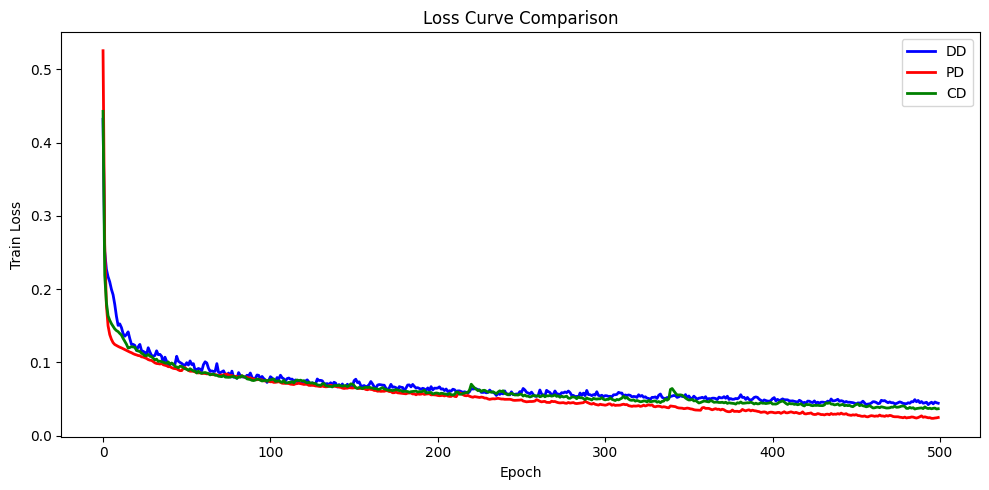

In [83]:
import csv
import matplotlib.pyplot as plt

csv_files = [
    "./models_and_results/model_weights/DD_loss_and_others.csv",
    "./models_and_results/model_weights/PD_loss_and_others.csv",
    "./models_and_results/model_weights/CD_loss_and_others.csv"
]

labels = ["DD", "PD", "CD"]  
colors = ["blue", "red", "green"]

plt.figure(figsize=(10, 5))

for file, label, color in zip(csv_files, labels, colors):
    loss_list = []
    
    with open(file, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)  
        
        for row in reader:
            loss = float(row[2])
            loss_list.append(loss)
    
    plt.plot(loss_list, label=label, color=color, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Loss Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig('./mloss.png')
plt.show()